# Genes used in spatial aging clocks

This notebook determines the genes used for each of the cell type-specific spatial aging clocks and constructs plots and a supplementary table containing this information.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy.stats import pearsonr, spearmanr, ttest_ind
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib.collections import PatchCollection
import seaborn as sns
from sklearn.neighbors import BallTree

import upsetplot as up
import gseapy as gp

os.chdir("/labs/abrunet1/Eric/MERFISH")

In [2]:
restricted_celltype_subset = ['Neuron-Excitatory','Neuron-MSN','Astrocyte','Microglia','Oligodendrocyte','OPC','Endothelial','Pericyte','VSMC','Ependymal','Neuroblast','NSC','Macrophage', 'T cell']

In [3]:
def upset_plot_coefs (coefs_df, tag, threshold=0, min_subset_size=1):
    '''
    Takes the output file of get_coefficients.py [on Sherlock] and saves an upset plot
    tag = "Lasso", "Dirty", "Naive"
    threshold = min abs expression to be considered a "clock" gene
    '''
    coefs_df = coefs_df.T
    gene_names = list(coefs_df.T.columns)
    
    counts_data = [[] for i in range(coefs_df.shape[0])]

    for model in coefs_df.columns:
        coef_vector = coefs_df[model]
        for k in np.where(np.abs(coef_vector) > threshold)[0]:
            counts_data[k].append(model)

    counts_dict = {}
    # Using Iteration
    for lis in counts_data:
        counts_dict.setdefault(tuple(lis), list()).append(1)
    for a, b in counts_dict.items():
        counts_dict[a] = sum(b)
    # get into upset data format
    upset_data = up.from_memberships([list(k) for k in list(counts_dict.keys())], data=list(counts_dict.values()))
    
    # make plot
    up.plot(upset_data, sort_categories_by='cardinality', sort_by='cardinality',
            min_subset_size=min_subset_size, max_subset_size=1e4,)
    plt.savefig(os.path.join('plots/clocks',tag+'_upset.pdf'))
    plt.show()

## Clock genes

In [4]:
adata = sc.read_h5ad("data/integrated_aging_coronal_celltyped_regioned_raw.h5ad")
adata = adata[(adata.obs.clusters!="1")&(adata.obs.mouse_id!="89")&(adata.obs.mouse_id!="67")].copy()

In [ ]:
name = "lasso_cv5_nalphas20_spatialsmooth_alpha08_neigh20"

celltypes = ['Neuron-Excitatory', 'Neuron-Inhibitory', 'Neuron-MSN',
                    'Astrocyte', 'Microglia', 'Oligodendrocyte', 'OPC',
                    'Endothelial', 'Pericyte', 'VSMC', 'VLMC',
                    'Ependymal', 'Neuroblast', 'NSC', 
                    'Macrophage', 'Neutrophil','T cell', 'B cell']


#######################
gene_names = adata.var_names
coefficients = []

for ct in celltypes:
        
    if f'{name}_{ct}.pkl' in os.listdir('results/clocks'): # if there exist clock for cell type
        
        # load and apply aging clock
        with open(f'results/clocks/{name}_{ct}.pkl', 'rb') as handle:
            pipeline = pickle.load(handle)
            
        coefficients.append(pipeline[1].coef_)
        
coefs_df = pd.DataFrame(np.vstack(coefficients), columns=gene_names, index=celltypes)

In [ ]:
# Creates Supplementary Table
coefs_df.T.to_csv("supp_tables/TableS3_ClockCoefficients.csv")

### Make upset plot

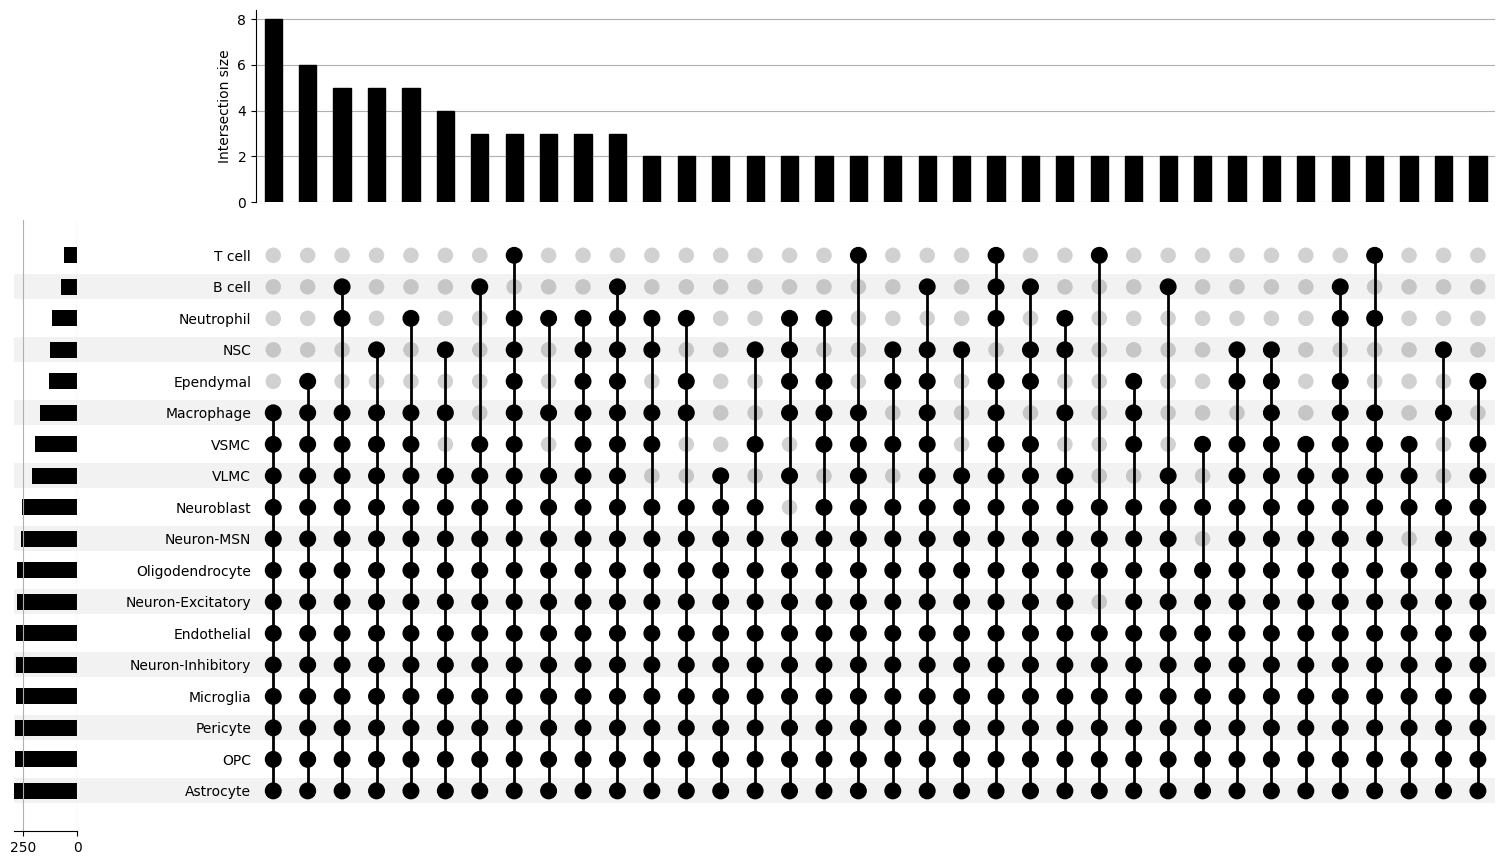

In [6]:
upset_plot_coefs(coefs_df, name, min_subset_size=2)

In [7]:
nz_coefs_df = coefs_df.copy()
nz_coefs_df[np.abs(nz_coefs_df)>0] = 1
nz_coefs_df[np.abs(nz_coefs_df)<=0] = 0
num_genes = nz_coefs_df.sum(axis=1)

In [8]:
num_genes.astype(int)

Neuron-Excitatory    279
Neuron-Inhibitory    283
Neuron-MSN           260
Astrocyte            292
Microglia            284
Oligodendrocyte      277
OPC                  287
Endothelial          282
Pericyte             286
VSMC                 195
VLMC                 211
Ependymal            130
Neuroblast           254
NSC                  126
Macrophage           173
Neutrophil           117
T cell                62
B cell                74
dtype: int64